# Correlation Analysis
Measures how BTC returns relate to ~40 macro and market variables (FRED, Yahoo Finance) at daily, weekly and monthly frequency.

Flow: BTC data -> macro panels -> remove redundant variables -> correlations -> lead-lag -> stability over time.

All settings live in the configuration cell below; the logic lives in `btc_data.py`, `macro_panel.py` and `corr_tools.py`.

## Configuration

In [1]:
import gc  # Garbage collector
import pandas as pd
import matplotlib.pyplot as plt

from btc_data import load_btc, return_summary, plot_return_hists
from macro_panel import load_raw, build_panels
from corr_tools import (TARGETS, prune_panels, corr_summary, resolve_focus,
                        lead_lag, corr_by_year, heatmap, rolling_corr_plot)

START = "2017-01-01"        # start of the analysis (before 2017 BTC was very small/illiquid)
METHOD = "spearman"         # correlation method (robust to fat tails)
PRUNE_THRESHOLD = 0.85      # max |r| allowed between two macro variables
TOP = 12                    # rows shown in each correlation table
FOCUS = ["SP500", "DXY", "US10Y", "Gold", "VIX", "HY_OAS", "NetLiquidity"]  # a-priori shortlist
MAX_LAG = {"D": 5, "W": 4}  # lead-lag range, in periods of each frequency
ROLL_WINDOW = 180           # rolling-correlation window, in daily observations

## BTC data
Loads the 1-minute CSV (downloading it from Kaggle if it is not local) and keeps only the daily, weekly and monthly OHLCV frames.
The result is cached on disk, so later runs skip the 1-minute file; the summary below uses log returns, the same definition as the rest of the analysis.
Heavy tails (high excess kurtosis) are one reason the correlations use Spearman.

In [2]:
btc = load_btc()                                       # {"D", "W", "ME"} OHLCV frames
close = {f: df["Close"] for f, df in btc.items()}
display(return_summary(btc).round(3))
gc.collect()

Using existing dataset: c:\Users\adria\My Drive\TAMAU\Git\Proyecto IAI\IAI600-final-project\Correlation Analyses\btcusd_1-min_data.csv


,start,n,mean,std,skew,excess_kurtosis,min,max
D,2012-01-01,5396,0.179973,4.072592,-1.306201,25.396459,-66.394803,33.748619
W,2012-01-01,771,1.259578,10.589142,0.002906,4.108347,-59.369607,53.985417
ME,2012-01-31,177,5.453716,24.812199,1.958751,11.356298,-46.632483,170.479276


20

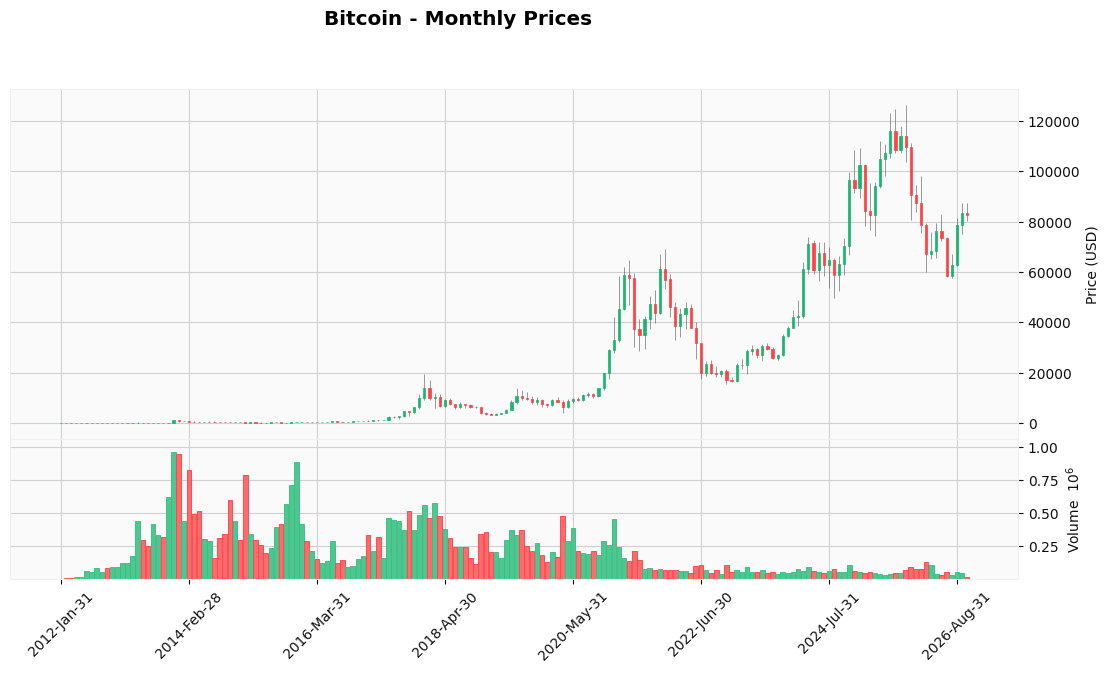

In [3]:
import mplfinance as mpf

mpf.plot(btc["ME"], type="candle", style="yahoo", title="Bitcoin - Monthly Prices",
         ylabel="Price (USD)", volume=True, figsize=(14, 7))

## Macro panels
Downloads the macro and market variables once and builds one panel per frequency, aligned by observation date (`pit=False`), so it measures co-movement rather than prediction.
Each variable is transformed (log return or difference) after alignment, so slow series are never correlated with fine-grained data.
The daily panel uses weekdays only, and variables slower than the panel frequency (e.g. CPI) only enter the slower panels.

In [4]:
macro = load_raw()                                          # downloads (or reads cache) once
panels, meta = build_panels(close, macro, start=START)
print({f: p.shape for f, p in panels.items()})
gc.collect()

{'D': (2550, 31), 'W': (511, 36), 'ME': (118, 46)}


642

### Data coverage
Shows the variables with the lowest fraction of non-missing observations in their panel.
Low coverage may mean truncated history (e.g. licensed series on FRED) or a discontinued series.
Check this before interpreting any correlation.

In [5]:
cov = pd.concat([p.drop(columns=list(TARGETS)).notna().mean() for p in panels.values()])
cov = cov.groupby(level=0).first()                          # finest panel where each variable appears
display(cov.sort_values().head(10).to_frame("fraction_with_data").join(meta[["source", "id", "group"]]))

,fraction_with_data,source,id,group
HY_OAS,0.307059,FRED,BAMLH0A0HYM2,credit
WTI,0.999216,Yahoo,CL=F,commodities
CPI,1.000000,FRED,CPIAUCSL,inflation
Breakeven10Y,1.000000,FRED,T10YIE,rates
Copper,1.000000,Yahoo,HG=F,commodities
CoreCPI,1.000000,FRED,CPILFESL,inflation
CorePCE,1.000000,FRED,PCEPILFE,inflation
Brent,1.000000,Yahoo,BZ=F,commodities
Curve_10Y3M,1.000000,FRED,T10Y3M,rates
DXY,1.000000,Yahoo,DX-Y.NYB,fx


## Redundancy among macro variables
Removes variables that are almost duplicates of another macro variable (|r| above `PRUNE_THRESHOLD`), keeping the one that is less redundant with the rest.
Only the correlation between macro variables is used, never the one with BTC, so the pruning does not bias the results interpreted below.
When two variables are redundant, the one in `FOCUS` is kept. The table lists what was dropped and which variable stands in for it.

In [6]:
panels, pruned = prune_panels(panels, threshold=PRUNE_THRESHOLD, method=METHOD, prefer=FOCUS)
display(pruned.round(2))
print({f: p.shape[1] - len(TARGETS) for f, p in panels.items()}, "variables kept per panel")

,kept_instead,abs_r,panel
US30Y,TLT,0.96,D
Brent,WTI,0.93,D
NASDAQ,SP500,0.93,D
TLT,US10Y,0.91,D
Curve_10Y3M,US10Y,0.86,D
PCE,CPI,0.91,ME


{'D': 24, 'W': 29, 'ME': 38} variables kept per panel


## Correlations with BTC
Ranks every remaining variable by its correlation with the BTC return (`r_ret`) and with its absolute value (`r_abs`), i.e. the size of the move rather than its direction.
`q_*` is the p-value adjusted for multiple comparisons (FDR): with this many variables, several would look significant by chance alone.
Monthly results rest on ~110 observations, so treat them with extra caution.

In [7]:
for f, name in {"D": "DAILY (weekdays)", "W": "WEEKLY", "ME": "MONTHLY"}.items():
    print(f"\n=== {name} ===")
    display(corr_summary(panels[f], METHOD).round(3).head(TOP))


=== DAILY (weekdays) ===


,n,r_ret,q_ret,r_abs,q_abs
var,,,,,
Russell2000,2550,0.257,0.0,-0.037,0.256
HY_OAS,783,-0.256,0.0,-0.020,0.702
SP500,2550,0.236,0.0,-0.037,0.256
HYG,2550,0.198,0.0,-0.050,0.256
VIX,2550,-0.196,0.0,0.044,0.256
USD_broad,2550,-0.147,0.0,-0.023,0.436
Silver,2550,0.147,0.0,0.029,0.414
EuroStoxx50,2550,0.145,0.0,-0.020,0.488
DXY,2550,-0.129,0.0,-0.018,0.501



=== WEEKLY ===


,n,r_ret,q_ret,r_abs,q_abs
var,,,,,
HY_OAS,156,-0.272,0.002,0.123,0.484
Russell2000,511,0.257,0.000,-0.046,0.625
VIX,511,-0.231,0.000,0.057,0.486
SP500,511,0.228,0.000,-0.060,0.486
EuroStoxx50,511,0.202,0.000,-0.101,0.221
NFCI,511,-0.189,0.000,0.078,0.455
HYG,511,0.182,0.000,-0.057,0.486
Nikkei,511,0.120,0.023,-0.064,0.484
USD_broad,511,-0.119,0.023,-0.008,0.968



=== MONTHLY ===


,n,r_ret,q_ret,r_abs,q_abs
var,,,,,
SP500,117,0.366,0.002,0.136,0.493
NFCI,117,-0.322,0.008,-0.027,0.893
HYG,117,0.287,0.017,0.103,0.706
NetLiquidity,117,0.285,0.017,0.162,0.432
Russell2000,117,0.278,0.018,0.140,0.493
Breakeven10Y,117,0.272,0.019,-0.098,0.706
VIX,117,-0.233,0.061,-0.193,0.277
Real10Y,117,-0.227,0.064,-0.131,0.493
EuroStoxx50,117,0.213,0.087,0.135,0.493


## Lead-lag
Uses panels built with `pit=True` (availability date), so each value only appears when it was actually known, for the shortlist in `FOCUS` (variables pruned above are replaced by the one kept instead).
Shows the correlation between BTC returns and each variable shifted by k periods; k>0 means the variable leads BTC.
A stronger correlation at k>0 than at k=0 would suggest predictive content; a peak only at k=0 is just co-movement.

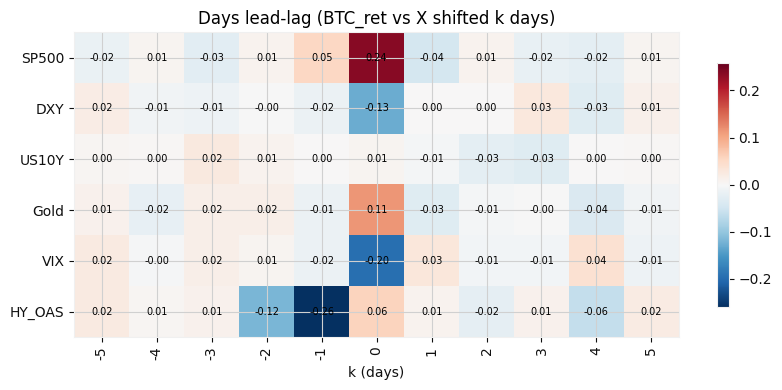

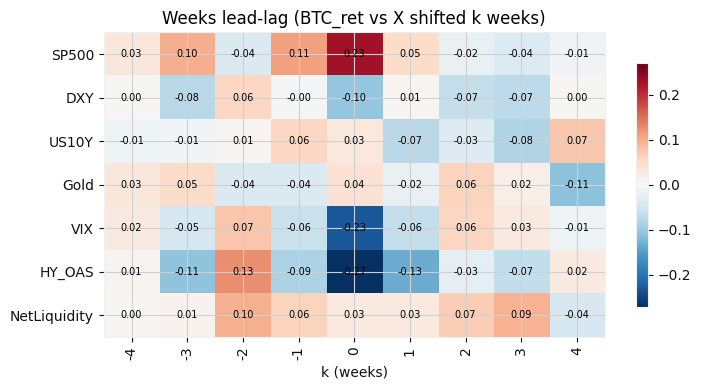

42957

In [8]:
focus = resolve_focus(FOCUS, panels, pruned)
kept = sorted({c for p in panels.values() for c in p.columns} - set(TARGETS))
panels_pit, _ = build_panels(close, macro, pit=True, freqs=tuple(MAX_LAG), start=START, variables=kept)

units = {"D": "days", "W": "weeks"}
for f, k in MAX_LAG.items():
    vars_f = [v for v in focus if v in panels_pit[f].columns]
    heatmap(lead_lag(panels_pit[f], max_lag=k, variables=vars_f, method=METHOD),
            f"{units[f].capitalize()} lead-lag (BTC_ret vs X shifted k {units[f]})", xlabel=f"k ({units[f]})")
plt.show()
gc.collect()

## Stability over time
Tests whether the correlation with BTC stays similar through time or changes between regimes, for the same shortlist (daily panel).
Plots a rolling correlation (Pearson) and tabulates the Spearman correlation per calendar year.
With ~250 daily observations per year, small differences between years may be noise rather than a real regime change.

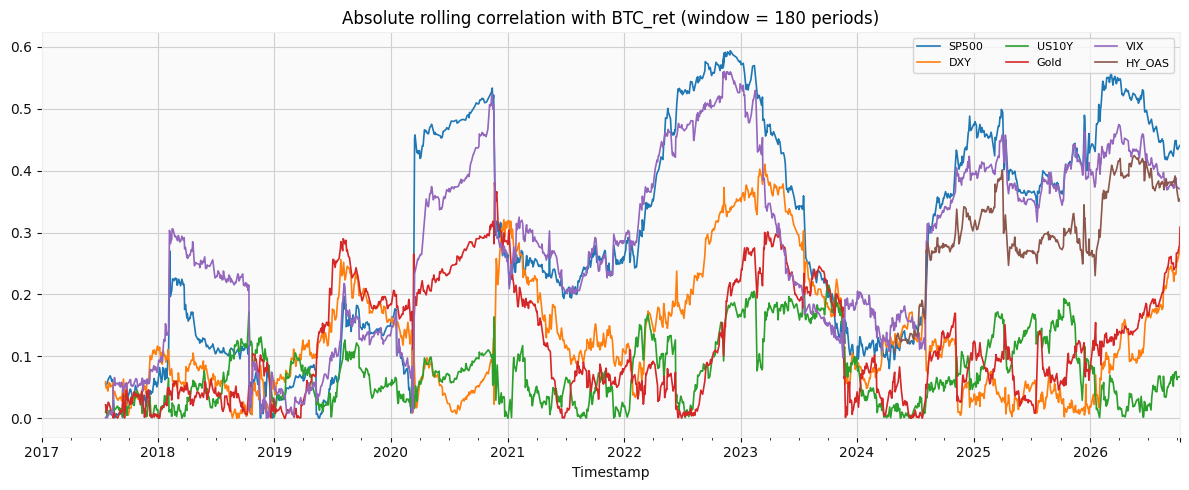

,SP500,DXY,US10Y,Gold,VIX,HY_OAS
2017,0.04,0.08,-0.03,0.02,-0.06,NaN
2018,0.05,-0.05,0.09,0.05,-0.02,NaN
2019,-0.02,-0.15,-0.02,0.13,0.03,NaN
2020,0.22,-0.12,0.08,0.31,-0.21,NaN
2021,0.25,-0.11,0.06,-0.07,-0.24,NaN
2022,0.56,-0.32,-0.06,0.09,-0.49,NaN
2023,0.23,-0.14,-0.06,0.09,-0.22,-0.20
2024,0.31,-0.18,0.01,0.15,-0.20,-0.17
2025,0.38,-0.08,0.08,0.10,-0.38,-0.30
2026,0.44,-0.24,-0.15,0.33,-0.31,-0.34


In [9]:
vars_d = [v for v in focus if v in panels["D"].columns]
rolling_corr_plot(panels["D"], vars_d, window=ROLL_WINDOW, absolute=True)
plt.show()
display(corr_by_year(panels["D"], vars_d, method=METHOD).round(2))

*NOTE: It is interesting that the drops in correlation for some variables is accompanied by an increase in some others*

## Appendix: distribution of BTC returns
Histogram of BTC log returns for each timeframe, clipped to the 1st-99th percentile to keep the bulk of the distribution visible.
The red line marks the mean. It is kept as a reference and does not feed the analysis above.

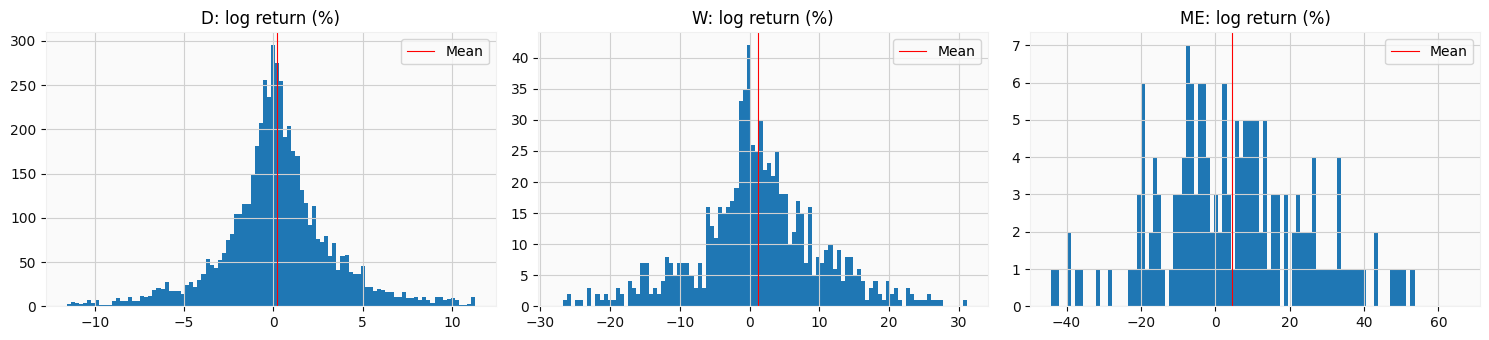

In [10]:
plot_return_hists(btc)
plt.show()